In [1]:
import torch 
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.pyplot as plt

data = torch.load('data/bout_ml_dataset.pt')

def create_animation(data):
    # Set consistent color scale across all frames
    vmin, vmax = data.min(), data.max()

    fig, ax = plt.subplots(figsize=(3, 3))
    im = ax.imshow(data[0], animated=True, vmin=vmin, vmax=vmax, cmap='viridis')

    def animate(frame):
        im.set_array(data[frame])
        ax.set_title(f'Time step {frame}')
        return [im]

    ani = animation.FuncAnimation(fig, animate, frames=data.shape[0], 
                                interval=500, blit=True, repeat=True)  # Slower: 500ms 
    return ani



In [2]:
data['constant_scalars'].shape, data.keys(), data['data'].shape 

(torch.Size([112, 6]),
 dict_keys(['data', 'constant_scalars', 'constant_fields']),
 torch.Size([112, 51, 64, 64, 1]))

In [3]:
from torch.utils.data import DataLoader
from autoemulate.experimental.data.spatiotemporal_dataset import AutoEmulateDataset
from torch.utils.data import DataLoader

dataset = AutoEmulateDataset(data_path=None, data=data, n_steps_input=1, n_steps_output=1, dtype=torch.float32)
# Split at trajectory level
n_trajectories = dataset.n_trajectories
train_traj_count = int(0.9 * n_trajectories)

# Get trajectory indices
train_traj_idxs = list(range(train_traj_count))
val_traj_idxs = list(range(train_traj_count, n_trajectories))

print(f"Train trajectories: {len(train_traj_idxs)}, Val trajectories: {len(val_traj_idxs)}")

# Create train data
train_data = {
    'data': data["data"][:train_traj_count],
    'constant_scalars': data["constant_scalars"][:train_traj_count],
    'constant_fields': data["constant_fields"]  # This is None, so just pass it through
}

# Create val data  
val_data = {
    'data': data["data"][train_traj_count:],
    'constant_scalars': data["constant_scalars"][train_traj_count:],
    'constant_fields': data["constant_fields"]  # This is None, so just pass it through
}

Created 5600 subtrajectory samples
Each input sample shape: torch.Size([1, 64, 64, 1])
Each output sample shape: torch.Size([1, 64, 64, 1])
Data type: torch.float32
Train trajectories: 100, Val trajectories: 12


In [4]:
train_dataset = AutoEmulateDataset(data_path=None, data=train_data, n_steps_input=3, n_steps_output=1, dtype=torch.float32)
val_dataset = AutoEmulateDataset(data_path=None, data=val_data, n_steps_input=3, n_steps_output=1, dtype=torch.float32)
train_loader = DataLoader(train_dataset)
val_loader = DataLoader(val_dataset)
batch = next(iter(val_loader))

Created 4800 subtrajectory samples
Each input sample shape: torch.Size([3, 64, 64, 1])
Each output sample shape: torch.Size([1, 64, 64, 1])
Data type: torch.float32
Created 576 subtrajectory samples
Each input sample shape: torch.Size([3, 64, 64, 1])
Each output sample shape: torch.Size([1, 64, 64, 1])
Data type: torch.float32


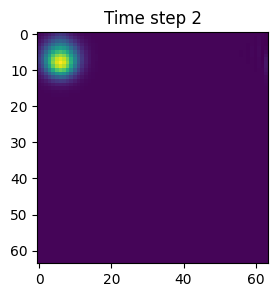

In [5]:
batch.keys()
batch['input_fields'].shape, batch['output_fields'].shape

HTML(create_animation(batch['input_fields'][0,:,:,:,0].cpu().numpy()).to_jshtml())

In [6]:
from autoemulate.experimental.emulators.fno import FNOEmulator

emulator = FNOEmulator(
    n_modes=(1, 16, 16),
    hidden_channels=16,
    in_channels=1,
    out_channels=1,)

In [7]:
emulator.fit(train_loader, None)

(0,)
sample     0, loss: 1.04795e+00
sample   100, loss: 2.69315e-03
sample   200, loss: 2.20619e-03
sample   300, loss: 1.23482e-03
sample   400, loss: 2.03324e-03
sample   500, loss: 1.40551e-03
sample   600, loss: 1.47112e-03
sample   700, loss: 1.62434e-03
sample   800, loss: 6.20343e-04
sample   900, loss: 6.70768e-04
sample  1000, loss: 4.22034e-04
sample  1100, loss: 1.54864e-04
sample  1200, loss: 8.03800e-04
sample  1300, loss: 7.16783e-04
sample  1400, loss: 1.17880e-03
sample  1500, loss: 6.47276e-04
sample  1600, loss: 7.23041e-04
sample  1700, loss: 6.13200e-04
sample  1800, loss: 5.03306e-04
sample  1900, loss: 7.72283e-04
sample  2000, loss: 1.73687e-03
sample  2100, loss: 6.55691e-04
sample  2200, loss: 2.08696e-03
sample  2300, loss: 7.86701e-04
sample  2400, loss: 5.94413e-04
sample  2500, loss: 1.10364e-03
sample  2600, loss: 5.57034e-04
sample  2700, loss: 2.16073e-03
sample  2800, loss: 4.65646e-04
sample  2900, loss: 1.15695e-03
sample  3000, loss: 1.95062e-03
sam

In [14]:
# Predictions
y_pred = emulator.predict(val_loader, with_grad=False)
y_pred.shape


torch.Size([576, 1, 1, 64, 64])

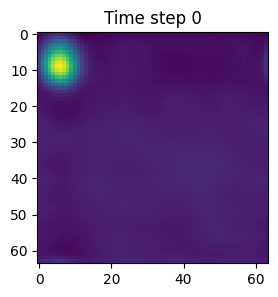

In [15]:

#plt.imshow(y_pred[400,0,2,:,:].cpu())

from IPython.display import HTML
HTML(create_animation(y_pred[0,0].cpu().numpy()).to_jshtml())

In [16]:
# Get initial sample
initial_sample = next(iter(val_loader))

# Autoregressive prediction
autoregressive_pred = emulator.predict_autoregressive(initial_sample, n_steps=30)
print(f"Autoregressive prediction shape: {autoregressive_pred.shape}")
print( autoregressive_pred[0, 0].shape)


torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
torch.Size([1, 1, 1, 64, 64])
Autoregressive prediction shape: torch.Size([1, 1, 30, 64, 64])
torch.Size([30, 64, 64])


In [17]:
import matplotlib.animation as animation

# Take first batch, first channel
data = autoregressive_pred[0, 0].cpu().numpy()  # [n_steps, height, width]

print(data.shape)
def create_animation(data):
    # Set consistent color scale across all frames
    vmin, vmax = data.min(), data.max()

    fig, ax = plt.subplots(figsize=(3, 3))
    im = ax.imshow(data[0], animated=True, vmin=vmin, vmax=vmax, cmap='viridis')

    def animate(frame):
        im.set_array(data[frame])
        ax.set_title(f'Time step {frame}')
        return [im]

    ani = animation.FuncAnimation(fig, animate, frames=data.shape[0], 
                                interval=500, blit=True, repeat=True)  # Slower: 500ms 
    return ani


(30, 64, 64)


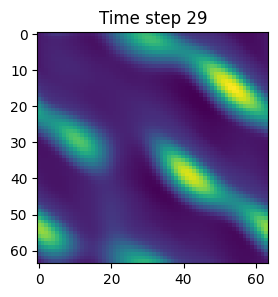

In [18]:
HTML(create_animation(data).to_jshtml())

In [13]:
# Save animation as GIF file
ani.save('autoregressive_prediction.gif', writer='pillow', fps=2)
print("Animation saved as autoregressive_prediction.gif")

NameError: name 'ani' is not defined

# traditional AR approach
$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$


In [ ]:
# Debug script to investigate the temporal structure
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. First, let's examine what's in your batch
batch = next(iter(train_loader))
print("Batch keys:", batch.keys())
print("Batch shapes:")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape}")

# 2. Let's look at the input_fields structure
input_fields = batch["input_fields"]  # Should be [batch, time, height, width, channels]
print(f"\nInput fields shape: {input_fields.shape}")
print(f"Expected format: [batch, time, height, width, channels]")

# 3. Let's visualize the 3 input time steps to see if they're consecutive
if len(input_fields.shape) == 5:  # [batch, time, height, width, channels]
    batch_idx = 0
    channel_idx = 0  # Look at first channel
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Input: 3 consecutive time steps (should be smooth progression)")
    
    for t in range(3):
        im = axes[t].imshow(input_fields[batch_idx, t, :, :, channel_idx])
        axes[t].set_title(f"Input Time Step {t}")
        axes[t].axis('off')
        plt.colorbar(im, ax=axes[t])
    
    plt.tight_layout()
    plt.show()

# 4. Now let's see what prepare_batch_fno does to this data
from autoemulate.experimental.emulators.batch_prep import prepare_batch_fno

x, y = prepare_batch_fno(
    batch, 
    channels=(0,),  # Use same channels as your emulator
    with_constants=True, 
    with_time=True
)

print(f"\nAfter prepare_batch_fno:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

# 5. Let's see what the model predicts
y_pred = emulator.model(x)
print(f"Model prediction shape: {y_pred.shape}")

# 6. Visualize the 3 predicted time steps
if len(y_pred.shape) == 5:  # [batch, channels, time, height, width]
    batch_idx = 0
    channel_idx = 0
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Model Output: 3 time steps (are these jumpy/inconsistent?)")
    
    for t in range(3):
        im = axes[t].imshow(y_pred[batch_idx, channel_idx, t, :, :].detach().cpu())
        axes[t].set_title(f"Predicted Time Step {t}")
        axes[t].axis('off')
        plt.colorbar(im, ax=axes[t])
    
    plt.tight_layout()
    plt.show()

# 7. Compare input vs output temporal progression
print("\n=== DEBUGGING QUESTIONS ===")
print("1. Do the 3 input time steps show smooth temporal progression?")
print("2. Do the 3 output time steps show smooth temporal progression?")
print("3. Are the output time steps related to the input time steps?")

# 8. Let's also check what the target looks like
if "output_fields" in batch:
    output_fields = batch["output_fields"]
    print(f"\nTarget output_fields shape: {output_fields.shape}")
    
    # Visualize target
    if len(output_fields.shape) == 5:
        plt.figure(figsize=(5, 5))
        plt.imshow(output_fields[0, 0, :, :, 0])  # First batch, first time, first channel
        plt.title("Target (what model should predict)")
        plt.colorbar()
        plt.show()